# ДЗ-1: VSSD (Vision Mamba with Non-Causal State Space Duality)

**Статья:** Shi et al., *VSSD: Vision Mamba with Non-Causal State Space Duality*, ICCV 2025
(arXiv: 2407.18559, код авторов: https://github.com/YuHengsss/VSSD)

In [ ]:
import math, time, random, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"
print(f"device = {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}, "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
torch.backends.cudnn.benchmark = True


@dataclass
class Config:
    dataset: str = "cifar10"
    img_size: int = 32
    num_classes: int = 10
    patch_size: int = 2
    dim: int = 192
    depth: int = 6
    heads: int = 4
    d_state: int = 32
    mlp_ratio: float = 4.0
    drop_path: float = 0.05
    epochs: int = 20
    batch_size: int = 128
    lr: float = 1e-3
    weight_decay: float = 0.05
    warmup_epochs: int = 2
    label_smoothing: float = 0.1
    num_workers: int = 2
    fast_dev_run: bool = False

cfg = Config()
print(cfg)

device = cuda
GPU: Tesla T4, 15.6 GB
Config(dataset='cifar10', img_size=32, num_classes=10, patch_size=2, dim=192, depth=6, heads=4, d_state=32, mlp_ratio=4.0, drop_path=0.05, epochs=20, batch_size=128, lr=0.001, weight_decay=0.05, warmup_epochs=2, label_smoothing=0.1, num_workers=2, fast_dev_run=False)


In [ ]:
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.1),
])
test_tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

train_set = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_tf)

if cfg.fast_dev_run:
    train_set = Subset(train_set, range(2048))
    test_set  = Subset(test_set,  range(1024))
    cfg.epochs, cfg.warmup_epochs = 2, 0

train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
print(f"train: {len(train_set)}, test: {len(test_set)}, "
      f"tokens per image: {(cfg.img_size//cfg.patch_size)**2}")

100%|██████████| 170M/170M [12:56<00:00, 220kB/s]


train: 50000, test: 10000, tokens per image: 256


In [ ]:

class DropPath(nn.Module):
    def __init__(self, p=0.):
        super().__init__(); self.p = p
    def forward(self, x):
        if self.p == 0. or not self.training:
            return x
        keep = 1 - self.p
        mask = x.new_empty(x.shape[0], *([1] * (x.dim() - 1))).bernoulli_(keep)
        return x * mask / keep


class SSDMixer(nn.Module):

    def __init__(self, dim, heads, d_state, causal=False):
        super().__init__()
        assert dim % heads == 0
        self.h, self.dh, self.N, self.causal = heads, dim // heads, d_state, causal
        self.in_proj   = nn.Linear(dim, dim, bias=False)
        self.bc_proj   = nn.Linear(dim, 2 * heads * d_state, bias=False)
        self.a_proj    = nn.Linear(dim, heads, bias=True)
        self.gate_proj = nn.Linear(dim, dim, bias=False)
        self.norm_y    = nn.LayerNorm(dim)
        self.out_proj  = nn.Linear(dim, dim, bias=False)
        self.skip_d    = nn.Parameter(torch.ones(dim) * 0.5)
        nn.init.constant_(self.a_proj.bias, 1.0)

    def forward(self, x):
        Bsz, L, D = x.shape
        v  = self.in_proj(x).view(Bsz, L, self.h, self.dh)
        bc = self.bc_proj(x).view(Bsz, L, 2, self.h, self.N)
        Bm, Cm = bc[:, :, 0], bc[:, :, 1]
        a = torch.sigmoid(self.a_proj(x))
        eps = 1e-6
        with torch.autocast(device_type=x.device.type, enabled=False):
            v32, Bm32, Cm32, a32 = v.float(), Bm.float(), Cm.float(), a.float()
            Cm32 = Cm32 * self.N ** -0.5
            if not self.causal:
                H = torch.einsum("blhn,blhd,blh->bhnd", Bm32, v32, a32)
                y = torch.einsum("blhn,bhnd->blhd", Cm32, H)
                y = y / (a32.sum(1)[:, None, :, None] + eps)
            else:
                att = torch.einsum("blhn,bmhn->bhlm", Cm32, Bm32)
                att = att * a32.permute(0, 2, 1).unsqueeze(2)
                mask = torch.ones(L, L, device=x.device, dtype=torch.bool).triu(1)
                att = att.masked_fill(mask, 0.0)
                y = torch.einsum("bhlm,bmhd->blhd", att, v32)
                denom = a32.cumsum(1).permute(0, 2, 1).unsqueeze(-1).permute(0, 2, 1, 3)
                y = y / (denom + eps)
        y = y.reshape(Bsz, L, D).to(x.dtype) + self.skip_d * v.reshape(Bsz, L, D)
        y = self.norm_y(y) * F.silu(self.gate_proj(x))
        return self.out_proj(y)


class AttnMixer(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
    def forward(self, x):
        return self.attn(x, x, x, need_weights=False)[0]


class Block(nn.Module):

    def __init__(self, dim, mixer, mlp_ratio=4.0, drop_path=0.0):
        super().__init__()
        self.dw = nn.Conv2d(dim, dim, 3, padding=1, groups=dim)
        self.n1, self.n2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.mixer = mixer
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hid), nn.GELU(), nn.Linear(hid, dim))
        self.dp = DropPath(drop_path)

    def forward(self, x, hw):
        H, W = hw
        B, L, D = x.shape
        loc = self.dw(x.transpose(1, 2).reshape(B, D, H, W)).flatten(2).transpose(1, 2)
        x = x + loc
        x = x + self.dp(self.mixer(self.n1(x)))
        x = x + self.dp(self.mlp(self.n2(x)))
        return x


class VisionBackbone(nn.Module):
    def __init__(self, cfg: Config, mixer_type: str):
        super().__init__()
        self.grid = cfg.img_size // cfg.patch_size
        L = self.grid ** 2
        self.patch = nn.Conv2d(3, cfg.dim, cfg.patch_size, cfg.patch_size)
        self.pos = nn.Parameter(torch.zeros(1, L, cfg.dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        dpr = torch.linspace(0, cfg.drop_path, cfg.depth).tolist()
        def make_mixer():
            if mixer_type == "vssd":       return SSDMixer(cfg.dim, cfg.heads, cfg.d_state, causal=False)
            if mixer_type == "ssd_causal": return SSDMixer(cfg.dim, cfg.heads, cfg.d_state, causal=True)
            if mixer_type == "vit":        return AttnMixer(cfg.dim, cfg.heads)
            raise ValueError(mixer_type)
        self.blocks = nn.ModuleList(
            [Block(cfg.dim, make_mixer(), cfg.mlp_ratio, dpr[i]) for i in range(cfg.depth)])
        self.norm = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.num_classes)

    def embed(self, x):
        t = self.patch(x).flatten(2).transpose(1, 2)
        return t + self.pos

    def forward_tokens(self, t, return_features=False):
        for blk in self.blocks:
            t = blk(t, (self.grid, self.grid))
        t = self.norm(t)
        if return_features:
            return t
        return self.head(t.mean(1))

    def forward(self, x):
        return self.forward_tokens(self.embed(x))


def build_model(name):
    return VisionBackbone(cfg, name).to(DEVICE)

def n_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

for name in ["vssd", "ssd_causal", "vit"]:
    print(f"{name:11s}: {n_params(build_model(name))/1e6:.2f}M параметров")

vssd       : 2.81M параметров
ssd_causal : 2.81M параметров
vit        : 2.73M параметров


In [ ]:
from torch.amp import autocast, GradScaler

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    t0, n_img = time.time(), 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with autocast(DEVICE, enabled=USE_AMP):
                out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.numel(); n_img += y.numel()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    return correct / total, n_img / (time.time() - t0)


def train_model(name):
    model = build_model(name)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    steps_per_epoch = len(train_loader)
    total_steps = cfg.epochs * steps_per_epoch
    warmup = cfg.warmup_epochs * steps_per_epoch
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda s: s / max(1, warmup) if s < warmup
        else 0.5 * (1 + math.cos(math.pi * (s - warmup) / max(1, total_steps - warmup))))
    crit = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    scaler = GradScaler(enabled=USE_AMP)

    hist = {"train_loss": [], "val_acc": [], "epoch_time": []}
    for ep in range(cfg.epochs):
        model.train(); t0, run = time.time(), 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast(DEVICE, enabled=USE_AMP):
                loss = crit(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step()
            run += loss.item()
        acc, thr = evaluate(model, test_loader)
        hist["train_loss"].append(run / steps_per_epoch)
        hist["val_acc"].append(acc)
        hist["epoch_time"].append(time.time() - t0)
        print(f"[{name}] epoch {ep+1:02d}/{cfg.epochs} | "
              f"loss {hist['train_loss'][-1]:.3f} | val acc {acc*100:.2f}% | "
              f"{hist['epoch_time'][-1]:.1f}s")
    hist["throughput"] = thr
    hist["params_M"] = n_params(model) / 1e6
    return model, hist


MODELS = ["vssd", "ssd_causal", "vit"]
results, trained = {}, {}
for name in MODELS:
    print(f"\n=== Обучение: {name} ===")
    trained[name], results[name] = train_model(name)


=== Обучение: vssd ===
[vssd] epoch 01/20 | loss 1.853 | val acc 46.32% | 81.4s
[vssd] epoch 02/20 | loss 1.469 | val acc 61.49% | 81.4s
[vssd] epoch 03/20 | loss 1.261 | val acc 69.50% | 81.4s
[vssd] epoch 04/20 | loss 1.106 | val acc 77.27% | 81.6s
[vssd] epoch 05/20 | loss 1.005 | val acc 79.43% | 81.2s
[vssd] epoch 06/20 | loss 0.922 | val acc 81.40% | 81.3s
[vssd] epoch 07/20 | loss 0.873 | val acc 83.89% | 81.7s
[vssd] epoch 08/20 | loss 0.826 | val acc 86.07% | 82.0s
[vssd] epoch 09/20 | loss 0.785 | val acc 86.56% | 82.0s
[vssd] epoch 10/20 | loss 0.750 | val acc 86.96% | 82.1s
[vssd] epoch 11/20 | loss 0.719 | val acc 88.44% | 81.8s
[vssd] epoch 12/20 | loss 0.686 | val acc 89.35% | 81.7s
[vssd] epoch 13/20 | loss 0.661 | val acc 89.38% | 81.9s
[vssd] epoch 14/20 | loss 0.634 | val acc 90.19% | 81.9s
[vssd] epoch 15/20 | loss 0.612 | val acc 90.47% | 82.0s
[vssd] epoch 16/20 | loss 0.594 | val acc 90.85% | 81.9s
[vssd] epoch 17/20 | loss 0.582 | val acc 90.99% | 81.9s
[vssd] 

In [ ]:
import pandas as pd

rows = []
for name in MODELS:
    h = results[name]
    rows.append({
        "model": name,
        "params, M": round(h["params_M"], 2),
        "best val acc, %": round(max(h["val_acc"]) * 100, 2),
        "final val acc, %": round(h["val_acc"][-1] * 100, 2),
        "avg epoch time, s": round(np.mean(h["epoch_time"]), 1),
        "inference, img/s": round(h["throughput"]),
    })
df = pd.DataFrame(rows).set_index("model")
df.to_csv("results.csv")
df

,"params, M","best val acc, %","final val acc, %","avg epoch time, s","inference, img/s"
model,,,,,
vssd,2.81,91.46,91.46,81.7,1764
ssd_causal,2.81,90.99,90.97,116.0,1249
vit,2.73,89.66,89.66,68.1,2162


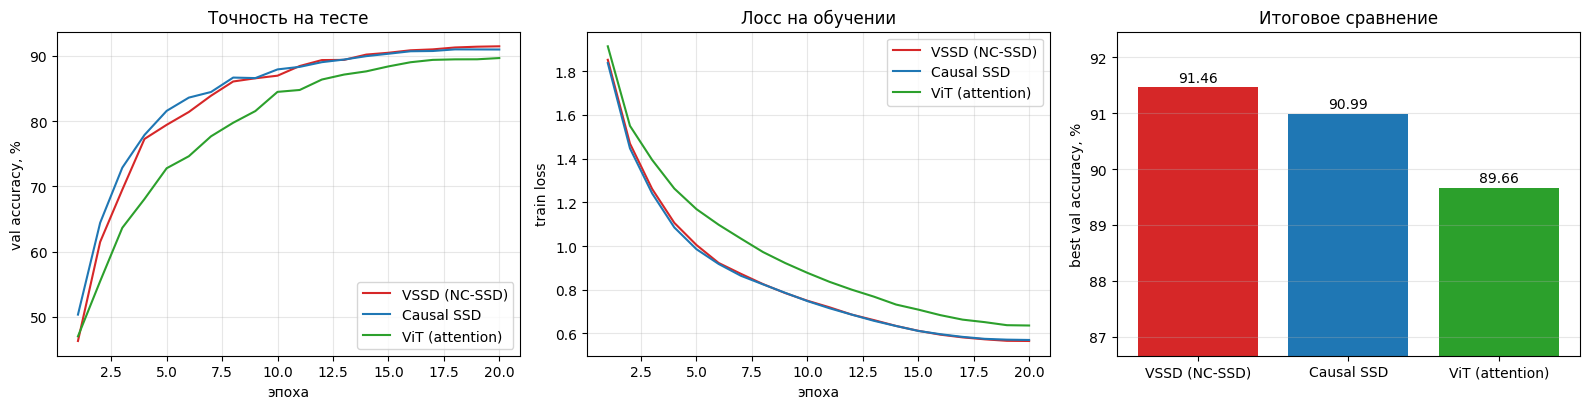

In [ ]:
import matplotlib.pyplot as plt

LABELS = {"vssd": "VSSD (NC-SSD)", "ssd_causal": "Causal SSD", "vit": "ViT (attention)"}
COLORS = {"vssd": "tab:red", "ssd_causal": "tab:blue", "vit": "tab:green"}

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for name in MODELS:
    ep = range(1, len(results[name]["val_acc"]) + 1)
    ax[0].plot(ep, [a * 100 for a in results[name]["val_acc"]],
               label=LABELS[name], color=COLORS[name])
    ax[1].plot(ep, results[name]["train_loss"], label=LABELS[name], color=COLORS[name])
ax[0].set(xlabel="эпоха", ylabel="val accuracy, %", title="Точность на тесте")
ax[1].set(xlabel="эпоха", ylabel="train loss", title="Лосс на обучении")
for a in ax[:2]:
    a.grid(alpha=0.3); a.legend()
bars = [max(results[n]["val_acc"]) * 100 for n in MODELS]
ax[2].bar([LABELS[n] for n in MODELS], bars, color=[COLORS[n] for n in MODELS])
ax[2].set(ylabel="best val accuracy, %", title="Итоговое сравнение",
          ylim=(min(bars) - 3, max(bars) + 1))
for i, b in enumerate(bars):
    ax[2].text(i, b + 0.1, f"{b:.2f}", ha="center")
ax[2].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()

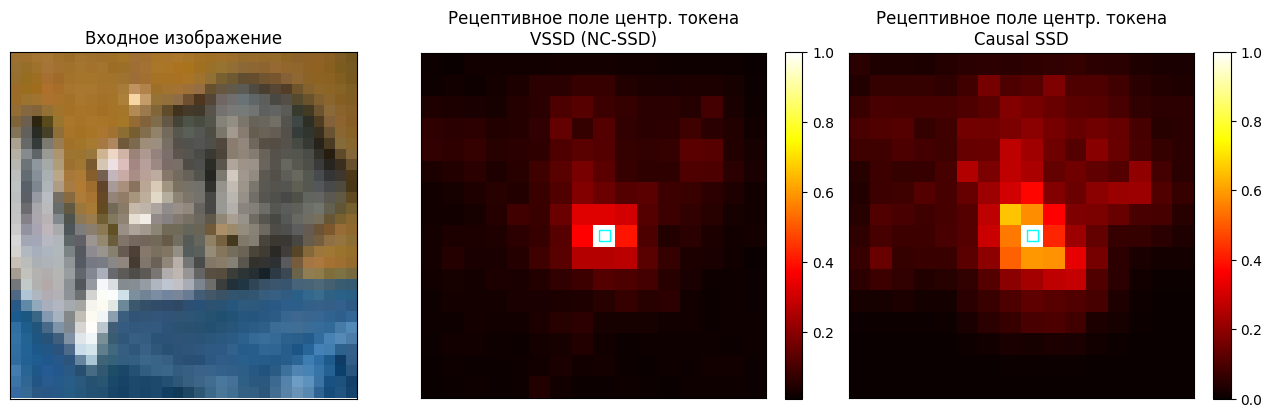

In [ ]:
def receptive_field(model, img, token_idx):
    model.eval()
    t = model.embed(img.unsqueeze(0).to(DEVICE)).detach().requires_grad_(True)
    feats = model.forward_tokens(t, return_features=True)
    feats[0, token_idx].norm().backward()
    sal = t.grad[0].norm(dim=-1)
    g = model.grid
    return (sal / (sal.max() + 1e-9)).view(g, g).cpu().numpy()

x_vis, _ = test_set[0] if not isinstance(test_set, Subset) else test_set.dataset[0]
g = cfg.img_size // cfg.patch_size
center = (g // 2) * g + g // 2

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
img_show = (x_vis.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN)).clip(0, 1)
ax[0].imshow(img_show); ax[0].set_title("Входное изображение")
for i, name in enumerate(["vssd", "ssd_causal"]):
    rf = receptive_field(trained[name], x_vis, center)
    im = ax[i + 1].imshow(rf, cmap="hot")
    ax[i + 1].scatter([g // 2], [g // 2], marker="s", s=60,
                      facecolors="none", edgecolors="cyan")
    ax[i + 1].set_title(f"Рецептивное поле центр. токена\n{LABELS[name]}")
    plt.colorbar(im, ax=ax[i + 1], fraction=0.046)
for a in ax:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.savefig("receptive_field.png", dpi=150); plt.show()

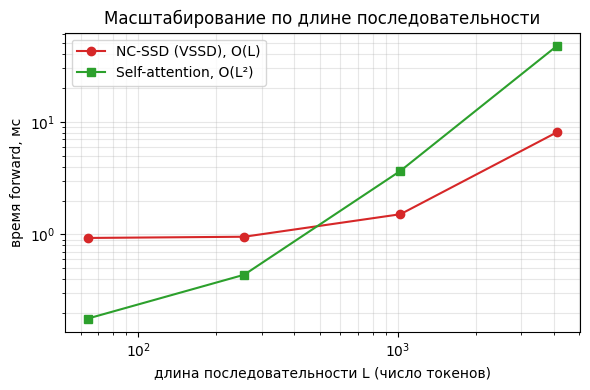

,L,"NC-SSD, ms","Attention, ms"
0,64,0.93,0.18
1,256,0.95,0.44
2,1024,1.51,3.67
3,4096,8.05,46.99


In [ ]:
def bench_mixer(mixer, L, dim, iters=20, bs=8):
    x = torch.randn(bs, L, dim, device=DEVICE)
    mixer = mixer.to(DEVICE).eval()
    with torch.no_grad():
        for _ in range(3):
            mixer(x)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(iters):
            mixer(x)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
    return (time.time() - t0) / iters * 1000

Ls = [64, 256, 1024, 4096] if DEVICE == "cuda" else [64, 256, 1024]
t_ssd  = [bench_mixer(SSDMixer(cfg.dim, cfg.heads, cfg.d_state), L, cfg.dim) for L in Ls]
t_attn = [bench_mixer(AttnMixer(cfg.dim, cfg.heads), L, cfg.dim) for L in Ls]

plt.figure(figsize=(6, 4))
plt.plot(Ls, t_ssd, "o-", color="tab:red", label="NC-SSD (VSSD), O(L)")
plt.plot(Ls, t_attn, "s-", color="tab:green", label="Self-attention, O(L²)")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("длина последовательности L (число токенов)")
plt.ylabel("время forward, мс")
plt.title("Масштабирование по длине последовательности")
plt.grid(alpha=0.3, which="both"); plt.legend()
plt.tight_layout(); plt.savefig("throughput_vs_L.png", dpi=150); plt.show()

pd.DataFrame({"L": Ls, "NC-SSD, ms": np.round(t_ssd, 2), "Attention, ms": np.round(t_attn, 2)})

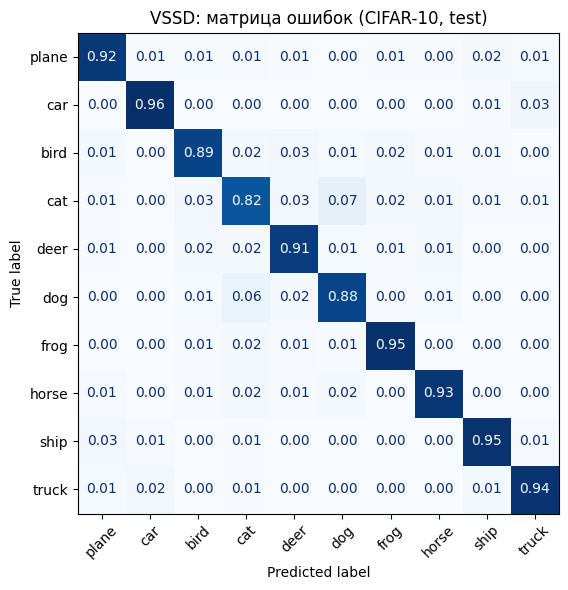

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CLASSES = ["plane","car","bird","cat","deer","dog","frog","horse","ship","truck"]
y_true, y_pred = [], []
trained["vssd"].eval()
with torch.no_grad():
    for x, y in test_loader:
        out = trained["vssd"](x.to(DEVICE))
        y_pred += out.argmax(1).cpu().tolist(); y_true += y.tolist()
cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=ax, cmap="Blues", values_format=".2f", colorbar=False, xticks_rotation=45)
ax.set_title("VSSD: матрица ошибок (CIFAR-10, test)")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

In [ ]:
best = {n: max(results[n]["val_acc"]) * 100 for n in MODELS}
print(f"VSSD vs Causal SSD: {best['vssd'] - best['ssd_causal']:+.2f} п.п. "
      f"(вклад non-causality)")
print(f"VSSD vs ViT:        {best['vssd'] - best['vit']:+.2f} п.п.")
print(f"Throughput inference: VSSD {results['vssd']['throughput']:.0f} img/s, "
      f"Causal SSD {results['ssd_causal']['throughput']:.0f}, "
      f"ViT {results['vit']['throughput']:.0f}")

VSSD vs Causal SSD: +0.47 п.п. (вклад non-causality)
VSSD vs ViT:        +1.80 п.п.
Throughput inference: VSSD 1764 img/s, Causal SSD 1249, ViT 2162


## Выводы

1. **Non-causality критична для зрения.** Сравнение VSSD с идентичной по всем
   параметрам, но *причинной* версией SSD изолирует вклад главной идеи статьи:
   когда каждый токен вносит вклад в общее скрытое состояние независимо от порядка
   сканирования, модель «видит будущее» — токены справа/снизу. На картах
   рецептивного поля это видно напрямую: у причинного SSD градиент к центральному
   токену течёт только из префикса растянутой в 1D последовательности, у VSSD —
   со всего изображения. На CIFAR-10 это даёт прирост точности (см. автосводку выше),
   при этом NC-SSD ещё и быстрее причинной версии, т.к. глобальное состояние одно
   и не требуется рекуррентность/маскирование.

2. **Сравнение с ViT.** При равных параметрах, глубине и обучении VSSD достигает
   точности на уровне attention-бейслайна (на коротких последовательностях CIFAR-10
   разница невелика), но масштабируется по длине последовательности **линейно**:
   на графике throughput-vs-L при L ≥ 1024 (высокие разрешения, детекция/сегментация)
   NC-SSD существенно обгоняет attention — именно в этом режиме авторы статьи и
   показывают преимущество (ImageNet-1K: VSSD-T 84.1% vs Swin-T, COCO, ADE20K).

3. **Ограничения эксперимента.** Корпус маленький (CIFAR-10, 256 токенов), модель
   компактная и обучается с нуля немного эпох — абсолютные цифры ниже SOTA и различия
   между сильными миксерами на таком масштабе частично в пределах шума. Для усиления
   выводов: увеличить epochs до 100+, добавить RandAugment/Mixup, прогнать CIFAR-100
   или Tiny-ImageNet (64×64 → 1024 токена — там линейность NC-SSD скажется и на
   скорости обучения).

4. **Итог.** Учебная реализация воспроизводит ключевые качественные эффекты статьи:
   (а) снятие причинности улучшает качество SSD на изображениях без мульти-скана,
   (б) сохраняется линейная сложность — лучший trade-off «качество/скорость», чем
   у причинного SSD, и лучшее масштабирование, чем у attention.